In [1]:
import json
import pathlib
from typing import List

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
class InputStream:
    def __init__(self, data):
        self.data = data
        self.i = 0

    def read(self, size):
        out = self.data[self.i : self.i + size]
        self.i += size
        return int(out, 2)


def access_bit(data, num):
    """from bytes array to bits by num position"""
    base = int(num // 8)
    shift = 7 - int(num % 8)
    return (data[base] & (1 << shift)) >> shift


def bytes2bit(data):
    """get bit string from bytes data"""
    return "".join([str(access_bit(data, i)) for i in range(len(data) * 8)])


def rle_to_mask(rle: List[int], height: int, width: int) -> np.array:
    """
    Converts rle to image mask
    Args:
        rle: your long rle
        height: original_height
        width: original_width

    Returns: np.array
    """

    rle_input = InputStream(bytes2bit(rle))

    num = rle_input.read(32)
    word_size = rle_input.read(5) + 1
    rle_sizes = [rle_input.read(4) + 1 for _ in range(4)]
    # print('RLE params:', num, 'values,', word_size, 'word_size,', rle_sizes, 'rle_sizes')

    i = 0
    out = np.zeros(num, dtype=np.uint8)
    while i < num:
        x = rle_input.read(1)
        j = i + 1 + rle_input.read(rle_sizes[rle_input.read(2)])
        if x:
            val = rle_input.read(word_size)
            out[i:j] = val
            i = j
        else:
            while i < j:
                val = rle_input.read(word_size)
                out[i] = val
                i += 1

    image = np.reshape(out, [height, width, 4])[:, :, 3]
    return image

In [5]:
export_file = pathlib.Path("/home/ruff/fhnw_code/load-simpla-annotations/data/label-exports/simpla-gruen-source-2026/simpla-gruen-source-2026.json")
image_dir = pathlib.Path("/home/ruff/fhnw_code/load-simpla-annotations/data/yolo-format/images")

In [6]:
with open(export_file, "r") as f:
    labels = json.load(f)

df_labels = pd.DataFrame(labels)

In [30]:
df_labels.head()  # Display the first few rows of the DataFrame

,id,annotations,drafts,predictions,data,meta,created_at,updated_at,inner_id,total_annotations,cancelled_annotations,total_predictions,comment_count,unresolved_comment_count,last_comment_updated_at,project,updated_by,comment_authors,file_upload
0,6656,"[{'id': 2882, 'completed_by': 1, 'result': [{'...",[],[],{'image': 's3://simpla-gruen-source-2026/Q3715...,{},2026-03-10T14:04:04.229551Z,2026-03-11T09:40:51.140786Z,1,1,0,0,0,0,None,3,1,[],NaN
1,6657,"[{'id': 2883, 'completed_by': 1, 'result': [{'...",[],[],{'image': 's3://simpla-gruen-source-2026/Q3715...,{},2026-03-10T14:04:04.236854Z,2026-03-11T09:44:49.899412Z,2,1,0,0,0,0,None,3,1,[],NaN
2,6658,"[{'id': 2884, 'completed_by': 1, 'result': [{'...",[],[],{'image': 's3://simpla-gruen-source-2026/Q3715...,{},2026-03-10T14:04:04.243374Z,2026-03-25T08:07:51.044511Z,3,1,0,0,0,0,None,3,1,[],NaN
3,6659,"[{'id': 2885, 'completed_by': 1, 'result': [{'...","[{'id': 4723, 'user': 'teddymicheva@gmail.com'...",[],{'image': 's3://simpla-gruen-source-2026/Q3715...,{},2026-03-10T14:04:04.249894Z,2026-03-11T09:51:41.107327Z,4,1,0,0,0,0,None,3,1,[],NaN
4,6660,"[{'id': 2886, 'completed_by': 1, 'result': [{'...",[],[],{'image': 's3://simpla-gruen-source-2026/Q3715...,{},2026-03-10T14:04:04.255204Z,2026-03-11T09:53:58.247559Z,5,1,0,0,0,0,None,3,1,[],NaN


In [34]:
df_labels.iloc[0]["data"].get("image")

's3://simpla-gruen-source-2026/Q3715-1.1c.JPG'

In [ ]:
# Filter rows where data["image"] contains a substring
search_term = "Q8184-45w.jpg"

filtered_df = df_labels[
    df_labels["data"]
    .apply(lambda d: d.get("image", "") if isinstance(d, dict) else "")
    .str.contains(search_term, case=False, na=False)
]

filtered_df[["id", "data"]].head()

KeyError: False

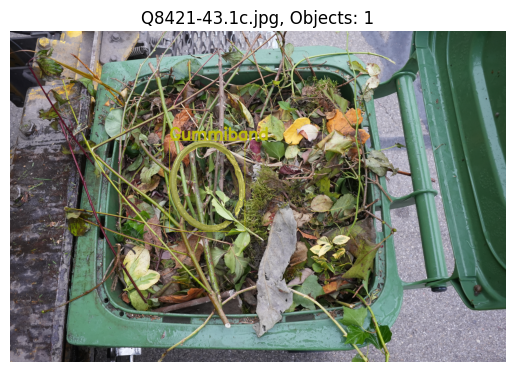

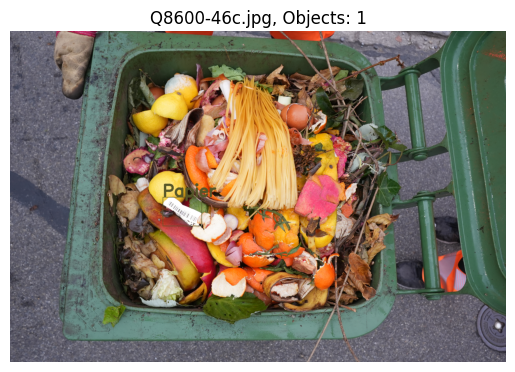

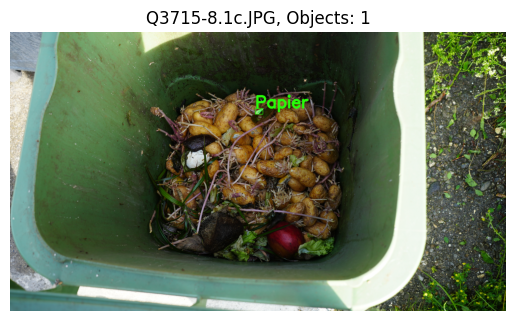

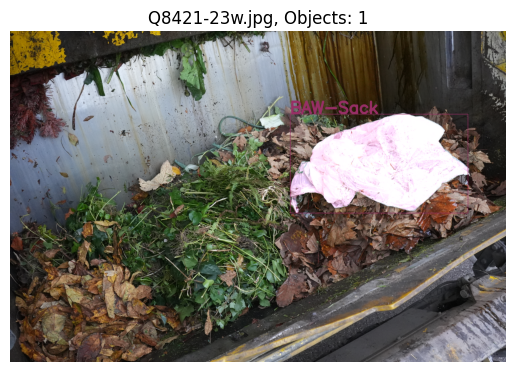

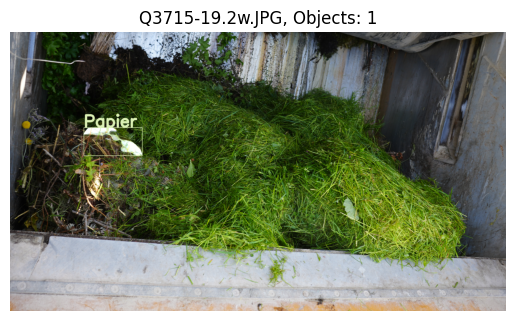

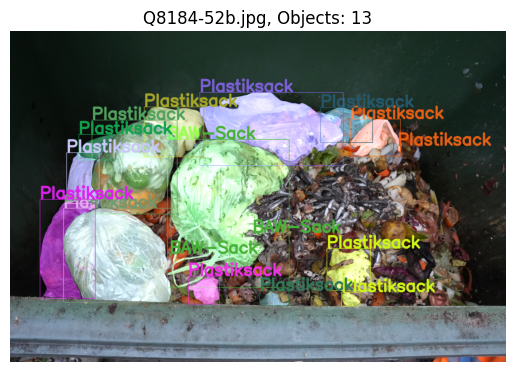

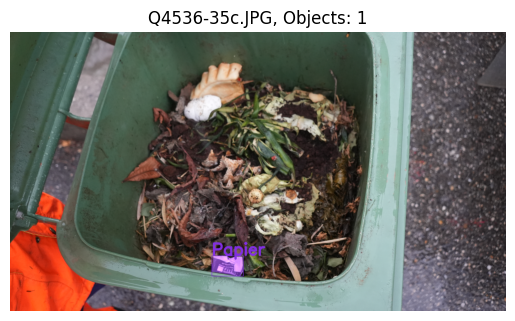

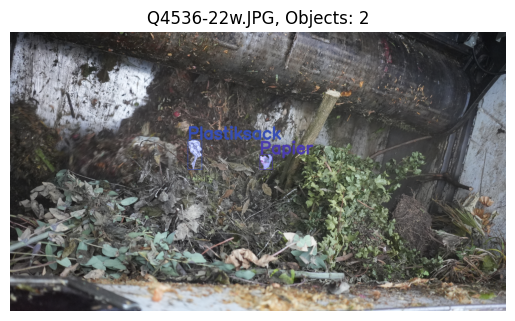

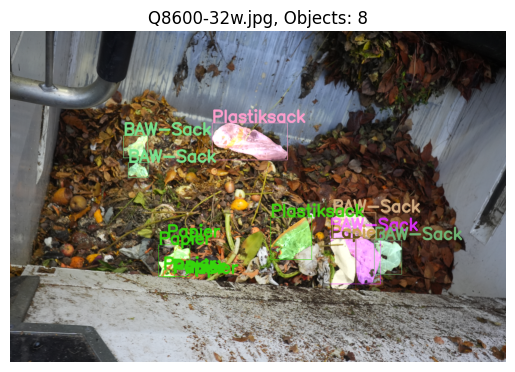

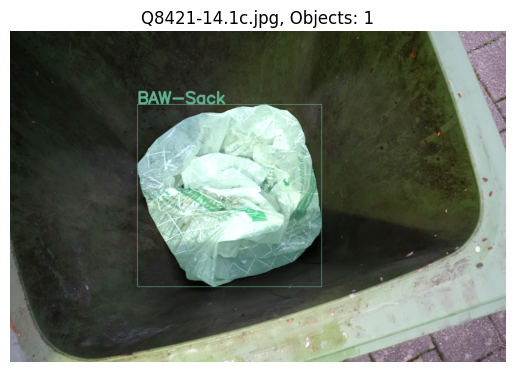

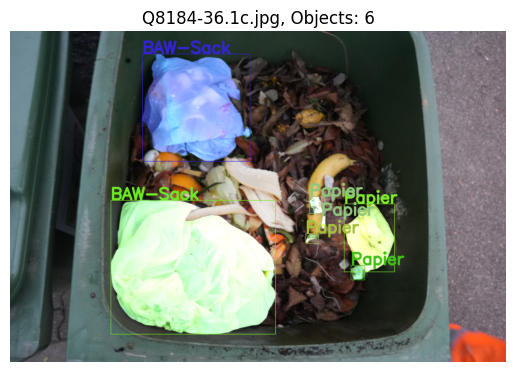

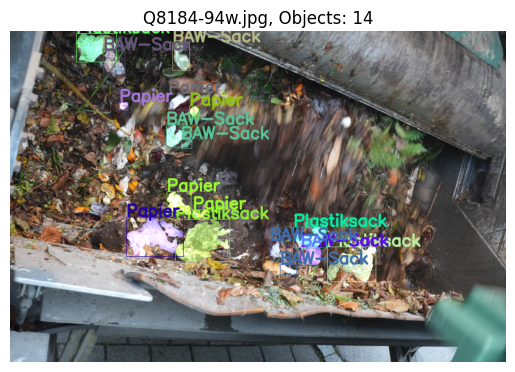

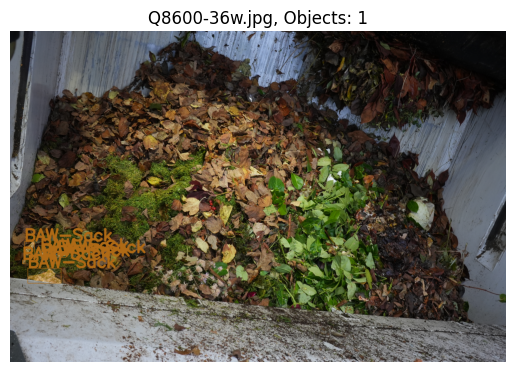

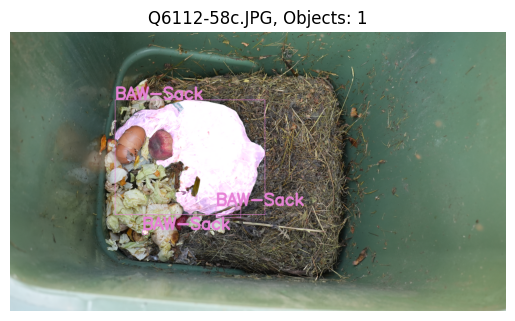

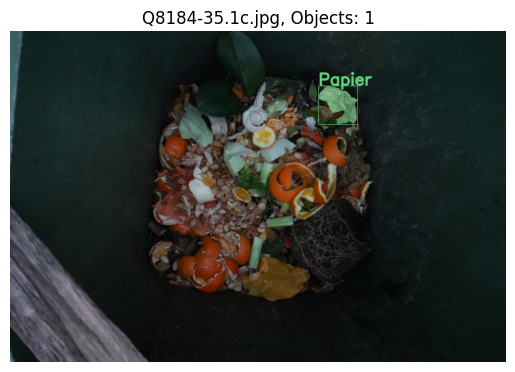

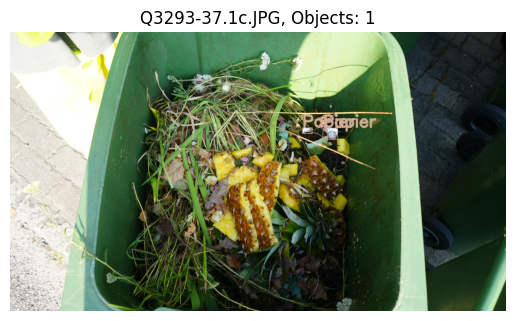

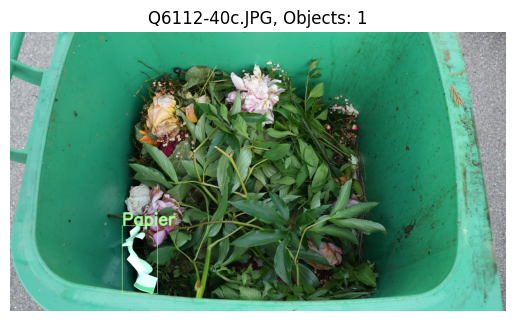

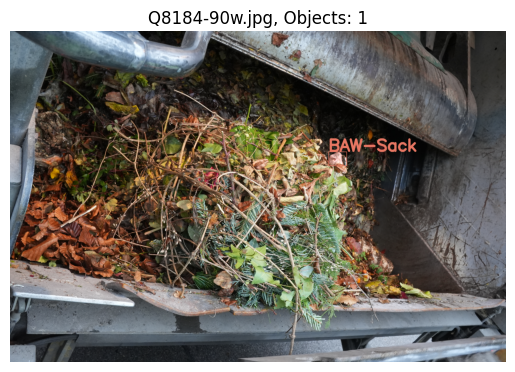

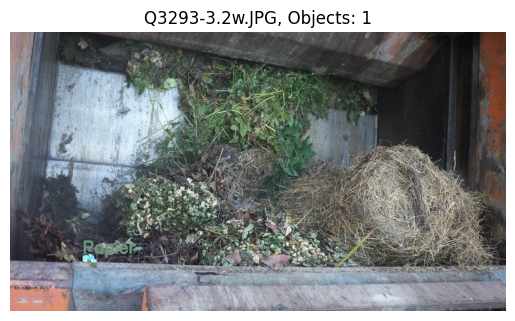

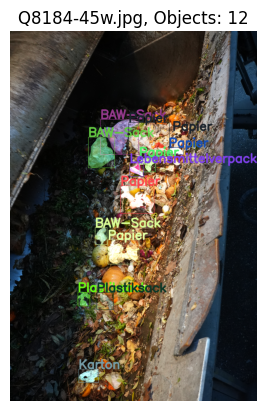

In [27]:
EXCLUDED_LABELS = {"container", "wagon", "Container", "Wagon"}

for data in df_labels.sample(n=50, random_state=42).itertuples():
    annotations = [
        annotation
        for annotation in data.annotations
        if annotation.get("result")
    ]
    if not annotations:
        continue
    for annotation in annotations:
        # Filter out individual results whose brushlabels are exclusively
        # "container" or "wagon"; keep results with any other label.
        filtered_results = [
            result
            for result in annotation.get("result", [])
            if not set(
                result.get("value", {}).get("brushlabels", [])
            ).issubset(EXCLUDED_LABELS)
        ]
        if not filtered_results:
            continue  # Skip if no results remain after filtering

        # The following code will execute only for annotations with results
        image_url = data.data.get("image")
        if not image_url:
            continue  # Skip if image url is not in data

        image_path = image_dir / image_url.split("/")[-1]

        if image_path.exists():
            img = cv2.imread(str(image_path))

            for result in filtered_results:
                if result["type"] == "keypointlabels":
                    continue
                value = result.get("value")
                if value.get("format") == "rle":
                    mask = rle_to_mask(
                        value.get("rle"),
                        result.get("original_height"),
                        result.get("original_width"),
                    )

                # validate mask before using it
                if mask is None:
                    continue
                if not isinstance(mask, np.ndarray):
                    try:
                        mask = np.asarray(mask)
                    except Exception:
                        continue

                # skip empty masks
                if mask.sum() == 0:
                    continue
                # Create a colored mask in a random color
                colored_mask = np.zeros_like(img)
                color = np.random.randint(0, 256, size=3, dtype=np.uint8)
                colored_mask[mask > 0] = color

                # Blend the original image and the colored mask
                img = cv2.addWeighted(img, 1, colored_mask, 0.5, 0)
                del mask  # Clean up mask variable for next iteration

                # derive binary mask from the colored mask (mask was deleted earlier)
                mask_bin = (np.any(colored_mask != 0, axis=2)).astype(np.uint8) * 255

                # find contours (compatibly handle different OpenCV return signatures)
                cnts = cv2.findContours(
                    mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )
                cnts = cnts[0] if len(cnts) == 2 else cnts[1]

                for cnt in cnts:
                    if cv2.contourArea(cnt) < 10:
                        continue
                    x, y, w, h = cv2.boundingRect(cnt)
                    # draw bounding box (green) and an optional label from brushlabels
                    cv2.rectangle(
                        img, (x, y), (x + w, y + h), color.tolist(), thickness=3
                    )
                    labels = (
                        value.get("brushlabels") if isinstance(value, dict) else None
                    )
                    if labels:
                        text = labels[0]
                        cv2.putText(
                            img,
                            text,
                            (x, max(0, y - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            5,
                            color.tolist(),
                            20,
                            cv2.LINE_AA,
                        )

            plt.figure()
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

            plt.title(f"{image_path.name}, Objects: {len(filtered_results)}")
            plt.axis("off")
            plt.show()
